In [46]:
import pandas as pd
df = pd.read_csv('LaptopData.csv')
df.drop('Unnamed: 0', axis=1, inplace=True)
df

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080
...,...,...,...,...,...,...,...,...,...,...,...
1298,Lenovo,2 in 1 Convertible,14,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i7 6500U 2.5GHz,4GB,128GB SSD,Intel HD Graphics 520,Windows 10,1.8kg,33992.6400
1299,Lenovo,2 in 1 Convertible,13.3,IPS Panel Quad HD+ / Touchscreen 3200x1800,Intel Core i7 6500U 2.5GHz,16GB,512GB SSD,Intel HD Graphics 520,Windows 10,1.3kg,79866.7200
1300,Lenovo,Notebook,14,1366x768,Intel Celeron Dual Core N3050 1.6GHz,2GB,64GB Flash Storage,Intel HD Graphics,Windows 10,1.5kg,12201.1200
1301,HP,Notebook,15.6,1366x768,Intel Core i7 6500U 2.5GHz,6GB,1TB HDD,AMD Radeon R5 M330,Windows 10,2.19kg,40705.9200


In [47]:
dfna = df[df['Company'].isna()]
dfna.shape

(30, 11)

In [48]:
df.dropna(subset = ['Company'], inplace=True)
df.shape

(1273, 11)

In [49]:
Avg = df['Price'].mean()
print(Avg)

59955.81407321288


In [50]:
df.describe()

,Price
count,1273.000000
mean,59955.814073
std,37332.251005
min,9270.720000
25%,31914.720000
50%,52161.120000
75%,79333.387200
max,324954.720000


In [51]:
Q1 = df['Price'].quantile(0.25)
Q1

np.float64(31914.72)

In [52]:
Q3 = df['Price'].quantile(0.75)
Q3

np.float64(79333.3872)

In [53]:
IQR = Q3 - Q1
Lowerbound_outlier = Q1 - 1.5 * IQR
Outerbound_outlier = Q3 + 1.5 * IQR
print(Lowerbound_outlier)
print(Outerbound_outlier)

-39213.28079999999
150461.38799999998


In [54]:
df_outlier = df[df['Price'] > Outerbound_outlier]
df_outlier

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
17,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.9GHz,16GB,512GB SSD,AMD Radeon Pro 560,macOS,1.83kg,152274.2400
196,Razer,Gaming,17.3,4K Ultra HD / Touchscreen 3840x2160,Intel Core i7 7820HK 2.9GHz,32GB,1TB SSD,Nvidia GeForce GTX 1080,Windows 10,3.49kg,324954.7200
204,Dell,Workstation,15.6,4K Ultra HD 3840x2160,Intel Xeon E3-1505M V6 3GHz,16GB,256GB SSD + 1TB HDD,Nvidia Quadro M1200,Windows 10,2.8kg,162770.4000
238,Asus,Gaming,17.3,Full HD 1920x1080,Intel Core i7 7820HK 2.9GHz,32GB,512GB SSD + 1TB HDD,Nvidia GeForce GTX 1080,Windows 10,4.7kg,207259.2000
247,Asus,Gaming,17.3,Full HD 1920x1080,Intel Core i7 7820HK 2.9GHz,16GB,256GB SSD,Nvidia GeForce GTX 1080,Windows 10,3.6kg,159786.7200
297,Dell,Workstation,17.3,Full HD 1920x1080,Intel Core i7 7820HQ 2.9GHz,16GB,256GB SSD,Nvidia Quadro M1200,Windows 10,3.42kg,153705.3408
517,Asus,Gaming,15.6,Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,24GB,512GB SSD,Nvidia GeForce GTX1080,Windows 10,2.24kg,158135.0400
530,Dell,Gaming,17.3,IPS Panel Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,16GB,128GB SSD + 1TB HDD,Nvidia GeForce GTX 1070,Windows 10,4.42kg,160520.3856
563,Lenovo,Notebook,17.3,IPS Panel Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,8GB,256GB SSD,Nvidia Quadro M620M,Windows 10,3.4kg,159786.7200
610,Lenovo,Notebook,15.6,IPS Panel 4K Ultra HD 3840x2160,Intel Xeon E3-1535M v6 3.1GHz,32GB,1TB SSD,Nvidia Quadro M2200M,Windows 10,2.5kg,261018.7200


In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

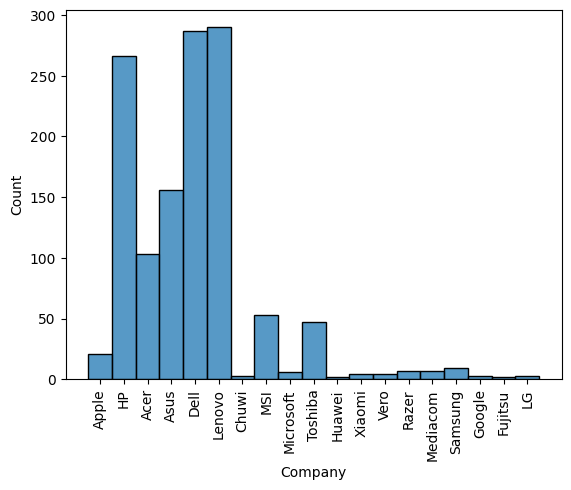

In [56]:
sns.histplot(df['Company'])
plt.xticks(rotation=90)
plt.show()

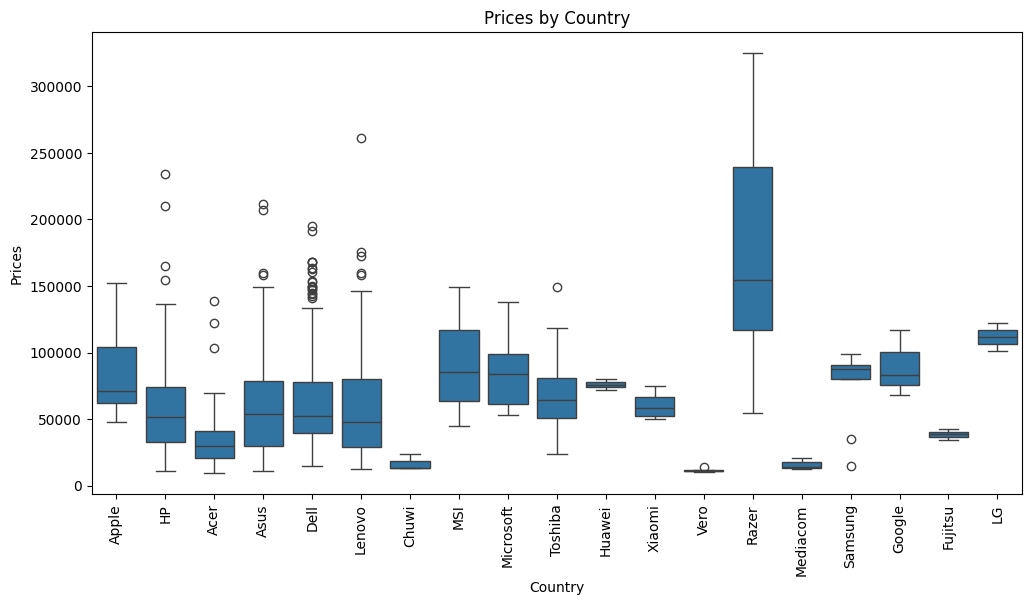

In [57]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='Company', y='Price', data=df)
plt.xticks(rotation=90)
plt.xlabel("Country")
plt.ylabel("Prices")
plt.title("Prices by Country")
plt.show()


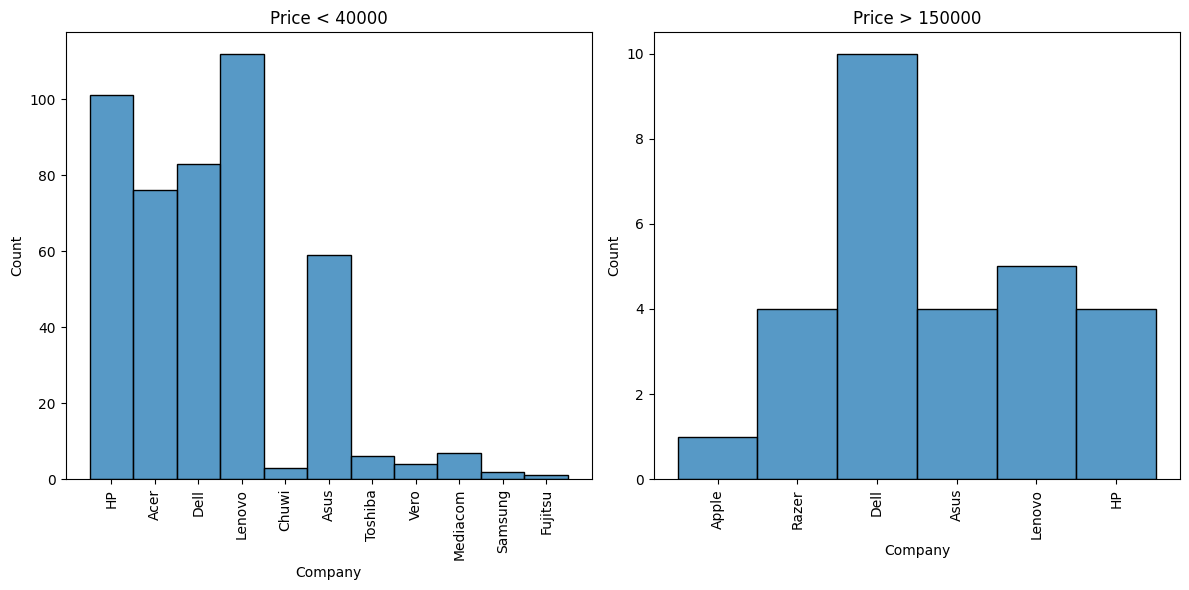

In [58]:
df_less_40000 = df[df['Price'] < 40000]
df_more_150000 = df[df['Price'] > 150000]
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.histplot(df_less_40000['Company'])
plt.xticks(rotation=90)
plt.title('Price < 40000')
plt.subplot(1, 2, 2)
sns.histplot(df_more_150000['Company'])
plt.xticks(rotation=90)
plt.title('Price > 150000')
plt.tight_layout()
plt.show()

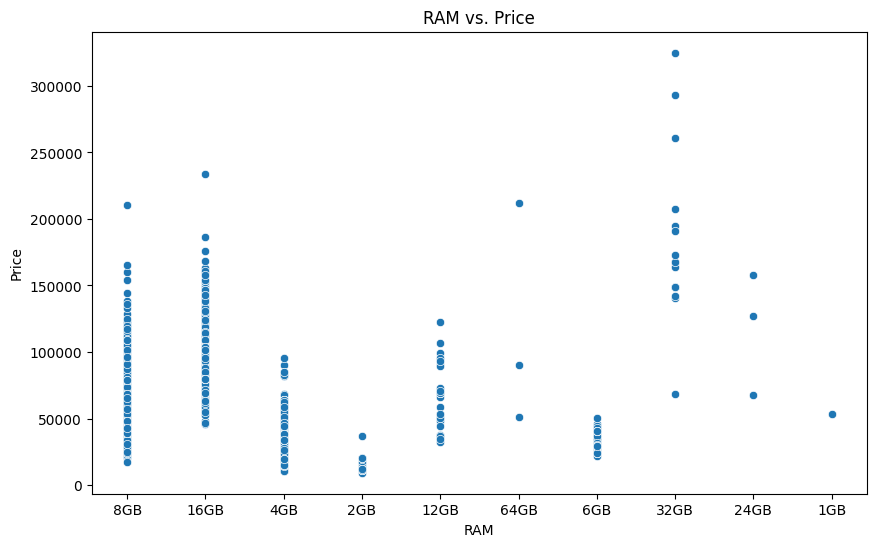

In [59]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Ram', y='Price', data=df)
plt.xlabel("RAM")
plt.ylabel("Price")
plt.title("RAM vs. Price")
plt.show()

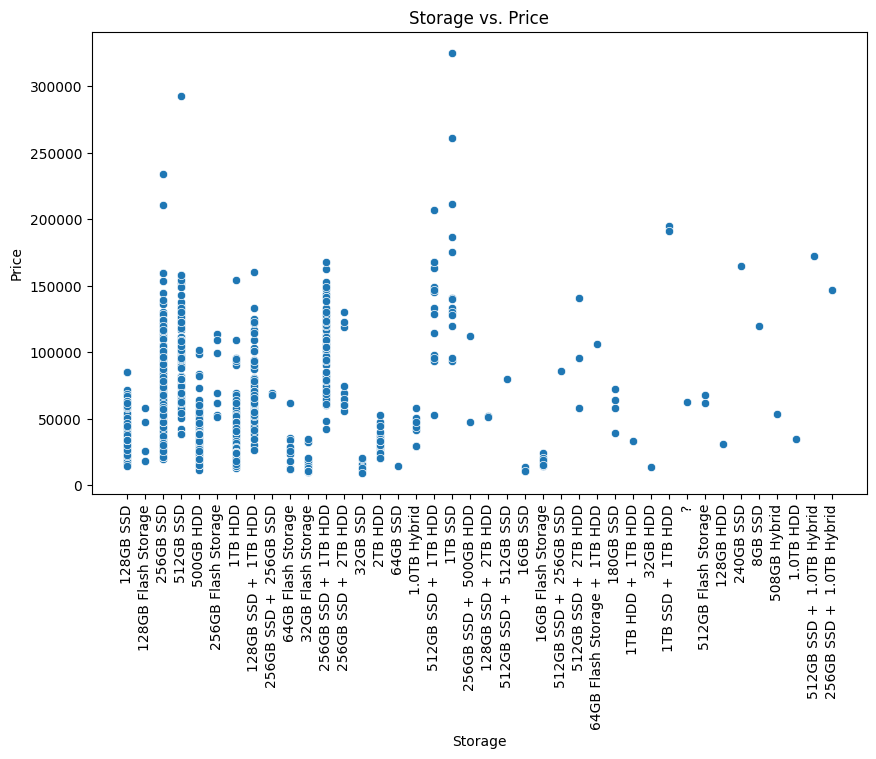

In [60]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Memory', y='Price', data=df)
plt.xlabel("Storage")
plt.ylabel("Price")
plt.title("Storage vs. Price")
plt.xticks(rotation=90)
plt.show()

In [61]:
SSD = []
HDD = []
Flash_Storage = []
Hybrid = []
for i in df['Memory']:
  if 'SSD' in i:
    SSD.append(i)

In [62]:
Memory_Type = []
for i in df['Memory']:
  if 'SSD' in i:
    Memory_Type.append('SSD')
  elif 'HDD' in i:
    Memory_Type.append('HDD')
  elif 'Flash Storage' in i:
    Memory_Type.append('Flash Storage')
  elif 'Hybrid' in i:
    Memory_Type.append('Hybrid')
  else:
    Memory_Type.append('Other')
df['Memory_Type'] = Memory_Type

In [63]:
df

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Memory_Type
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832,SSD
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232,Flash Storage
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000,SSD
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360,SSD
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080,SSD
...,...,...,...,...,...,...,...,...,...,...,...,...
1298,Lenovo,2 in 1 Convertible,14,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i7 6500U 2.5GHz,4GB,128GB SSD,Intel HD Graphics 520,Windows 10,1.8kg,33992.6400,SSD
1299,Lenovo,2 in 1 Convertible,13.3,IPS Panel Quad HD+ / Touchscreen 3200x1800,Intel Core i7 6500U 2.5GHz,16GB,512GB SSD,Intel HD Graphics 520,Windows 10,1.3kg,79866.7200,SSD
1300,Lenovo,Notebook,14,1366x768,Intel Celeron Dual Core N3050 1.6GHz,2GB,64GB Flash Storage,Intel HD Graphics,Windows 10,1.5kg,12201.1200,Flash Storage
1301,HP,Notebook,15.6,1366x768,Intel Core i7 6500U 2.5GHz,6GB,1TB HDD,AMD Radeon R5 M330,Windows 10,2.19kg,40705.9200,HDD


<Axes: ylabel='Count'>

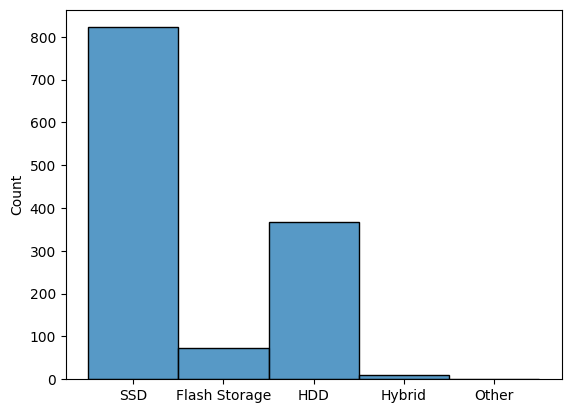

In [64]:
sns.histplot(Memory_Type)

<Axes: xlabel='Memory_Type', ylabel='Price'>

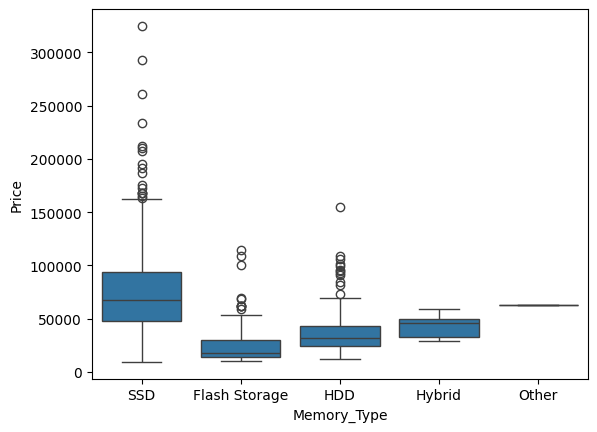

In [65]:
sns.boxplot(x='Memory_Type', y='Price', data=df)

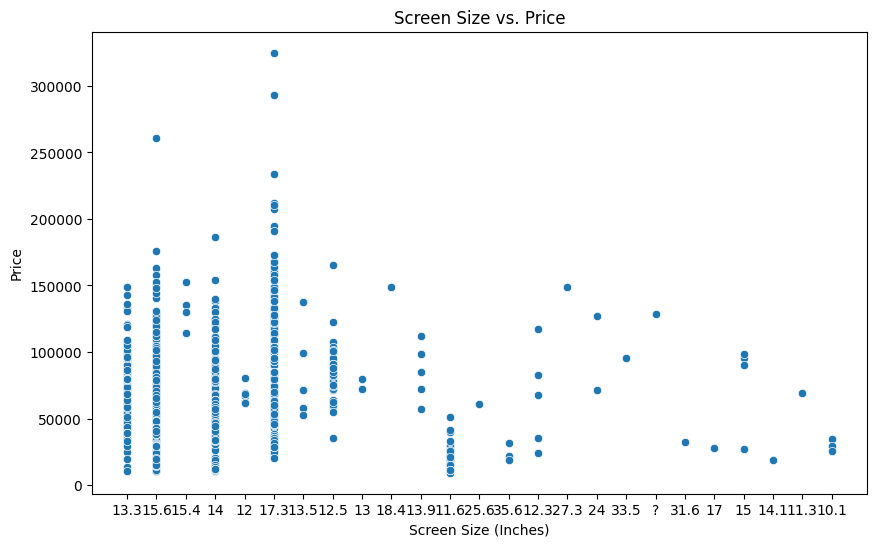

In [66]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Inches', y='Price', data=df)
plt.xlabel("Screen Size (Inches)")
plt.ylabel("Price")
plt.title("Screen Size vs. Price")
plt.show()

<ipython-input-67-bbbfa9e6fb3a>:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Cpu_Type', y='Price', data=df, estimator='mean', ci=None, palette='pastel')
<ipython-input-67-bbbfa9e6fb3a>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Cpu_Type', y='Price', data=df, estimator='mean', ci=None, palette='pastel')


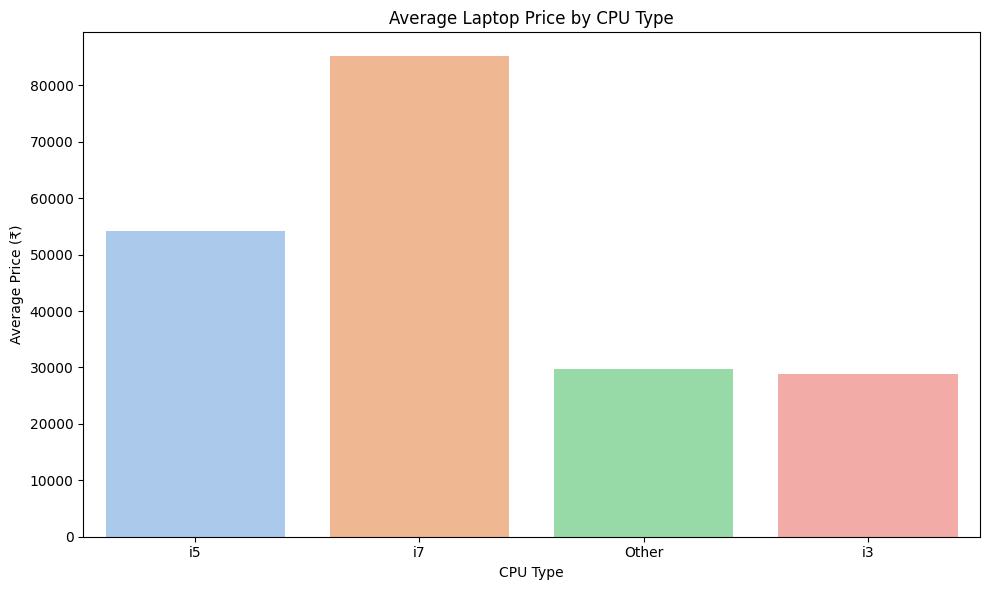

Average price of i5 laptops: ₹54230.52
Average price of i7 laptops: ₹85147.56


<ipython-input-67-bbbfa9e6fb3a>:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cpu_Type', y='Price', data=df[df['Cpu_Type'].isin(['i5', 'i7'])], palette='Set2')


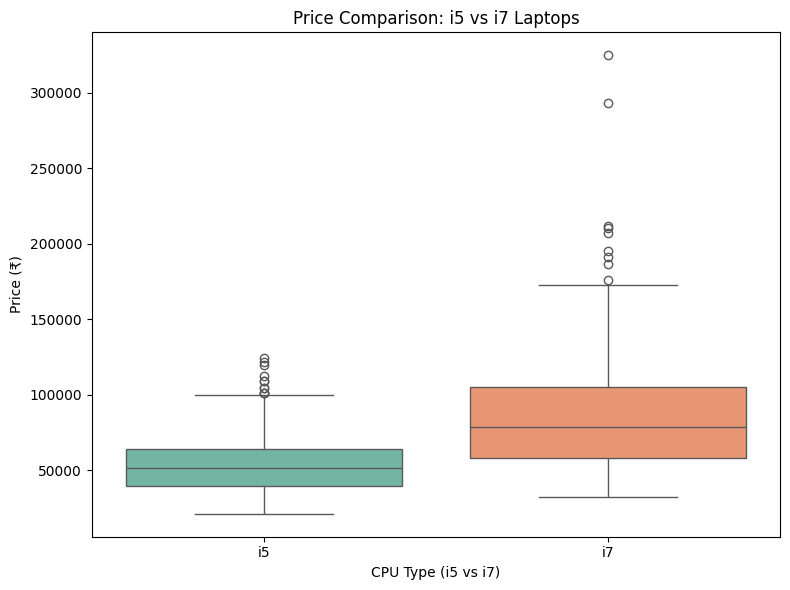

In [67]:
df['Cpu_Type'] = df['Cpu'].str.extract(r'(\b[Aa]md|\bi[3579])', expand=False)
df['Cpu_Type'] = df['Cpu_Type'].fillna('Other')
plt.figure(figsize=(10, 6))
sns.barplot(x='Cpu_Type', y='Price', data=df, estimator='mean', ci=None, palette='pastel')
plt.xlabel("CPU Type")
plt.ylabel("Average Price (₹)")
plt.title("Average Laptop Price by CPU Type")
plt.tight_layout()
plt.show()
i5_df = df[df['Cpu'].str.contains('i5', case=False, na=False)]
i7_df = df[df['Cpu'].str.contains('i7', case=False, na=False)]
print(f"Average price of i5 laptops: ₹{i5_df['Price'].mean():.2f}")
print(f"Average price of i7 laptops: ₹{i7_df['Price'].mean():.2f}")
plt.figure(figsize=(8, 6))
sns.boxplot(x='Cpu_Type', y='Price', data=df[df['Cpu_Type'].isin(['i5', 'i7'])], palette='Set2')
plt.xlabel("CPU Type (i5 vs i7)")
plt.ylabel("Price (₹)")
plt.title("Price Comparison: i5 vs i7 Laptops")
plt.tight_layout()
plt.show()


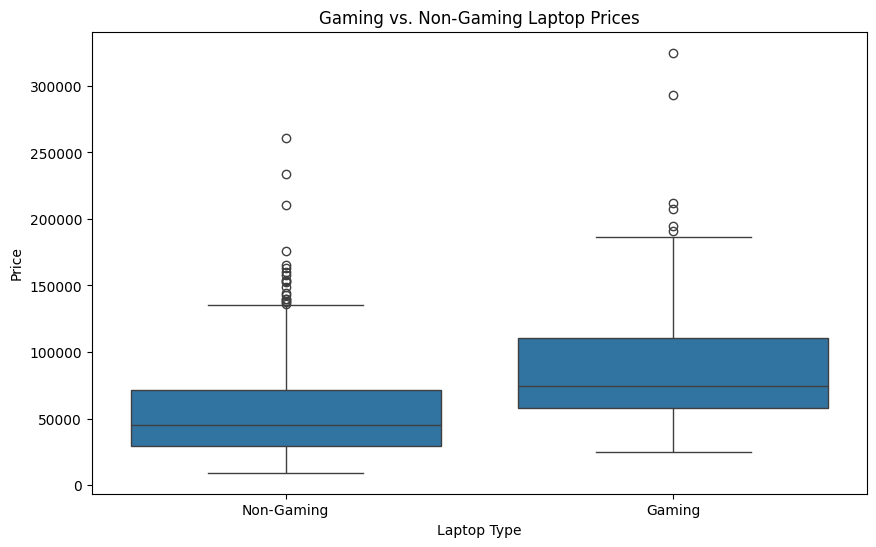

Gaming Laptop Price Range: 24988.32 - 324954.72
Non-Gaming Laptop Price Range: 9270.72 - 261018.72


In [68]:
df['Gaming'] = df['Gpu'].str.contains('GTX|RTX', case=False)

plt.figure(figsize=(10, 6))
sns.boxplot(x='Gaming', y='Price', data=df)
plt.xlabel("Laptop Type")
plt.ylabel("Price")
plt.title("Gaming vs. Non-Gaming Laptop Prices")
plt.xticks([0,1], ['Non-Gaming', 'Gaming'])
plt.show()

gaming_laptops = df[df['Gaming'] == True]
non_gaming_laptops = df[df['Gaming'] == False]

print("Gaming Laptop Price Range:", gaming_laptops['Price'].min(), "-", gaming_laptops['Price'].max())
print("Non-Gaming Laptop Price Range:", non_gaming_laptops['Price'].min(), "-", non_gaming_laptops['Price'].max())


Top 10 Laptops with Best Value for Money:
     Company  TypeName                                   Cpu  Ram     Memory  \
555     Asus  Notebook  Intel Celeron Dual Core N3350 1.1GHz  4.0  500GB HDD   
22        HP  Notebook          AMD E-Series E2-9000e 1.5GHz  4.0  500GB HDD   
340     Dell  Notebook  Intel Celeron Dual Core N3060 1.6GHz  4.0  500GB HDD   
1263    Acer  Notebook  Intel Celeron Dual Core N3060 1.6GHz  4.0  500GB HDD   
1291    Acer  Notebook  Intel Celeron Dual Core N3060 1.6GHz  4.0  500GB HDD   
1277    Acer  Notebook  Intel Celeron Dual Core N3060 1.6GHz  4.0  500GB HDD   
1151      HP  Notebook              AMD E-Series 7110 1.8GHz  4.0  500GB HDD   
717   Lenovo  Notebook               AMD A6-Series 7310 2GHz  4.0  500GB HDD   
1207  Lenovo  Notebook              AMD E-Series 9000 2.2GHz  4.0  500GB HDD   
503   Lenovo  Notebook  Intel Celeron Dual Core N3350 1.1GHz  4.0  500GB HDD   

          Price  Price_to_Performance_Ratio  
555   11934.720                

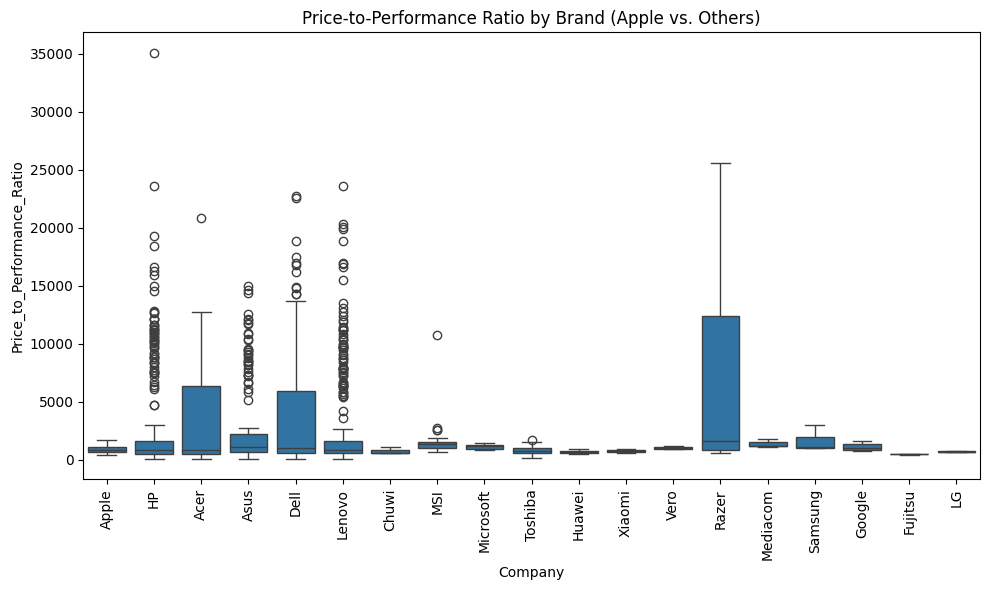

In [69]:
df['Ram'] = df['Ram'].astype(str).str.extract(r'(\d+)').astype(float)
df['Weight'] = df['Weight'].astype(str).str.extract(r'([\d.]+)')
df['Weight'] = pd.to_numeric(df['Weight'], errors='coerce')
df['Memory_Num'] = df['Memory'].astype(str).str.extract(r'(\d+)')
df['Memory_Num'] = pd.to_numeric(df['Memory_Num'], errors='coerce')
df[['Ram', 'Weight', 'Memory_Num']] = df[['Ram', 'Weight', 'Memory_Num']].fillna(0)
df['Benchmark_Score'] = (df['Ram'] * 0.4) + (df['Memory_Num'] * 0.3) + (df['Weight'] * 0.3)
df['Price_to_Performance_Ratio'] = df['Price'] / df['Benchmark_Score']
df_ranked = df.sort_values('Price_to_Performance_Ratio')
print("Top 10 Laptops with Best Value for Money:")
print(df_ranked[['Company', 'TypeName', 'Cpu', 'Ram', 'Memory', 'Price', 'Price_to_Performance_Ratio']].head(10))
brand_avg_ratio = df_ranked.groupby('Company')['Price_to_Performance_Ratio'].mean().sort_values()
print("\nAverage Price-to-Performance Ratio by Brand:")
print(brand_avg_ratio)
apple_ratio = df_ranked[df_ranked['Company'] == 'Apple']['Price_to_Performance_Ratio'].mean()
other_ratio = df_ranked[df_ranked['Company'] != 'Apple']['Price_to_Performance_Ratio'].mean()
print("\nAverage Price-to-Performance Ratio:")
print(f"- Apple: {apple_ratio:.2f}")
print(f"- Other Brands: {other_ratio:.2f}")
plt.figure(figsize=(10, 6))
selected = ['Apple'] + list(brand_avg_ratio.index[brand_avg_ratio.index != 'Apple'])
sns.boxplot(data=df[df['Company'].isin(selected)], x='Company', y='Price_to_Performance_Ratio')
plt.xticks(rotation=90)
plt.title('Price-to-Performance Ratio by Brand (Apple vs. Others)')
plt.tight_layout()
plt.show()


In [74]:
if 'Year' not in df.columns:
    print("No 'Year' column found in the dataset. Please extract or rename your year column.")
else:
    yearly_avg_price = df.groupby('Year')['Price'].mean().reset_index()
    plt.figure(figsize=(10, 6))
    sns.lineplot(x='Year', y='Price', data=yearly_avg_price, marker='o', color='blue')
    plt.title('Trend of Average Laptop Prices Over the Years')
    plt.xlabel('Year')
    plt.ylabel('Average Price (₹)')
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    print("Average price by year:")
    print(yearly_avg_price)


No 'Year' column found in the dataset. Please extract or rename your year column.
